In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load processed data
processed_data_path = '../data/processed/walmart_cleaned_features.csv'
df = pd.read_csv(processed_data_path)
df['Date'] = pd.to_datetime(df['Date'])

print(f"Processed dataset loaded for EDA! Total records: {len(df)}")
df.head()

Processed dataset loaded for EDA! Total records: 6435


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,WeekOfYear,DayOfWeek,Is_Extreme_Cold,Is_Extreme_Heat
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,4,0,0
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,4,0,0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,4,0,0
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,4,0,0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,4,0,0


C:\Users\ACER\AppData\Local\Temp\ipykernel_14724\3011624589.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=store_sales.head(5).index, y=store_sales.head(5).values, ax=axes[0], palette="Blues_r")
C:\Users\ACER\AppData\Local\Temp\ipykernel_14724\3011624589.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=store_sales.tail(5).index, y=store_sales.tail(5).values, ax=axes[1], palette="Reds_r")


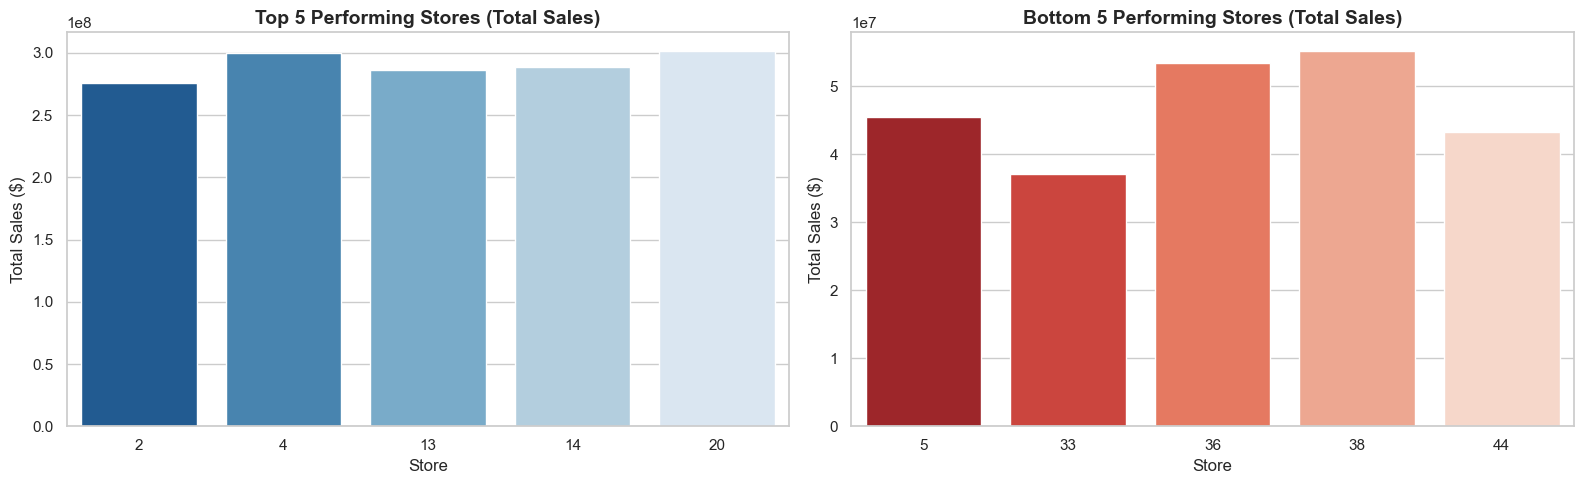

In [2]:
# Calculate total sales per store
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 5 Stores
sns.barplot(x=store_sales.head(5).index, y=store_sales.head(5).values, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 5 Performing Stores (Total Sales)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Total Sales ($)")

# Bottom 5 Stores
sns.barplot(x=store_sales.tail(5).index, y=store_sales.tail(5).values, ax=axes[1], palette="Reds_r")
axes[1].set_title("Bottom 5 Performing Stores (Total Sales)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_14724\2565736613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df, palette="Set2")


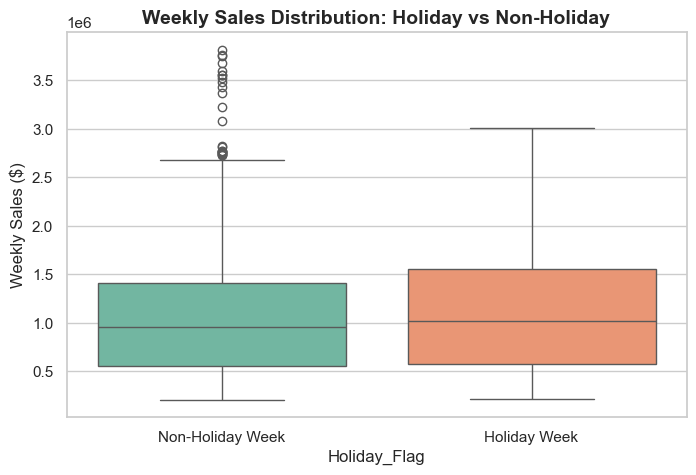

Average Non-Holiday Weekly Sales: $1,041,256.38
Average Holiday Weekly Sales:     $1,122,887.89
Holiday Demand Surge (Lift):     +7.84%


In [3]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df, palette="Set2")
plt.xticks([0, 1], ['Non-Holiday Week', 'Holiday Week'])
plt.title("Weekly Sales Distribution: Holiday vs Non-Holiday", fontsize=14, fontweight='bold')
plt.ylabel("Weekly Sales ($)")
plt.show()

# Print mean sales comparison
holiday_mean = df[df['Holiday_Flag'] == 1]['Weekly_Sales'].mean()
non_holiday_mean = df[df['Holiday_Flag'] == 0]['Weekly_Sales'].mean()
lift = ((holiday_mean - non_holiday_mean) / non_holiday_mean) * 100

print(f"Average Non-Holiday Weekly Sales: ${non_holiday_mean:,.2f}")
print(f"Average Holiday Weekly Sales:     ${holiday_mean:,.2f}")
print(f"Holiday Demand Surge (Lift):     +{lift:.2f}%")

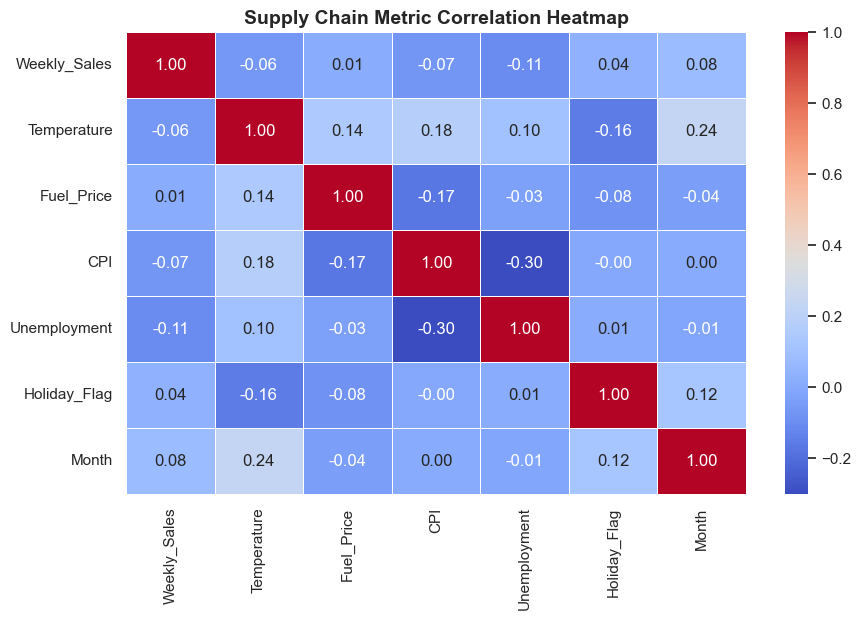

In [4]:
plt.figure(figsize=(10, 6))
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag', 'Month']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Supply Chain Metric Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()